**Copyright: © NexStream Technical Education, LLC**.  
All rights reserved

# Assignment 1 - From-scratch PCA Implementation

**Part 1:  Implement the PCA class**.  

In PCA, our goal is to reduce the number of dimensions represented by the independent variables (features) in our dataset.  We do this by transforming the features as linear combinations onto a new set of axes with reduced dimensionality.  The transformation will satisfy the following:
- Features are linearly independent (orthogonal).
- Dimensions are reduced based on projecting data onto axes which result in the largest variance, since this provides the most information about the data.
- The new dimensions will be created by projecting the original features onto transformed (e.g. rotated) axes.

<br>

The PCA class includes the following constructor and methods:
- def \__init__ (self, n_components):
- def _fit (self, X)_:
- def _transform(self, X)_:


<br>

_fit()_: calculates the 'n' Principal Components and Variance Ratios
  1. Calculate the mean of the input X.
  2. Center the data (subtract each feature mean from feature column).
  3. Calculate the covariance of the centered data.
  4. Perform eigenanalysis on cov matrix to calc eigenvalues, eigenvectors.
  5. Sort the eigenvalues and eigenvectors in decreasing order.
  6. Calculate the variance ratios for each eigenvalue ($\lambda_n$):   
  $ \text{variance ratio}_n = \frac{\lambda_n}{\sum \lambda} $
  7. Calculate the cumulative variance ratio

<br>

_transform()_: project the data onto the PC axes
- use NumPy dot product

<br>

Follow the steps outline in the following code cells.  

In [ ]:
#Imports
import numpy as np
import matplotlib.pyplot as plt

class PCA:
  def __init__(self, n_components):
    print('****** Created from-scratch PCA object *****')
    self.n_components = n_components
    self.components = None
    self.mean = None
    self.eigenvectors = None
    self.eigenvalues = None
    self.variance_ratio = None
    self.cumulative_var = None


  def fit(self, X):
  # Calculate n Principal Components (PCs) and Variance Ratios
  #   1. Calculate the mean of the input X.
  #   2. Center the data (subtract each feature mean from feature column).
  #   3. Calculate the covariance of the centered data.
  #   4. Perform eigenanalysis on cov matrix to calc eigenvalues, eigenvectors.
  #   5. Sort the eigenvalues and eigenvectors in decreasing order.
  #   6. Calculate the variance ratio for each eigenvalue
  #   7. Calculate the cumulative variance ratio

    #Calculate the mean and Center the data (X - X.mean)
    self.mean = np.mean(X,axis=0)
    X = X-self.mean

    #Calculate the Covariance
    #Need to transpose X since cov function assumes each example is in a column.
    #Hint: https://numpy.org/doc/stable/reference/generated/numpy.cov.html
    covariance = np.cov(X.T)

    #Perform eigenanalysis to calculate the eigenvectors and eigenvalues
    #Hint: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html
    #
    #Each returned eigenvalue (from hint function) corresponds
    #     to COLUMN vector in the returned eigenvector so will need
    #     eigenvector.T when use later to project data since uses dot product.
    self.eigenvalues, self.eigenvectors = np.linalg.eig(covariance)

    #Sort the eigenvectors based on the eigenvalues in decreasing order (largest eigenvalue first)
    #NOTE numpy doc for hint function states eigenvalues are not necessarily ordered.
    #     so use argsort() https://numpy.org/doc/stable/reference/generated/numpy.argsort.html.
    #     argsort() will return index in increasing order (smallest eigenvalue index first).
    #     We want largest eigenvalue index first (decreasing order), can use argsort()[::-1]
    #self.eigenvectors = self.eigenvectors.T           #transpose eigenvectors
    eigenvalue_idxs = np.argsort(self.eigenvalues)[::-1]                 #get indices in decreasing order
    self.eigenvalues = self.eigenvalues[eigenvalue_idxs]              #sort eigenvalues (decreasing order)
    self.eigenvectors = self.eigenvectors[:,eigenvalue_idxs]             #sort eigenvalues (decreasing order)

    #Store the number of Principal Components (PCs) to keep.
    #Since eigenvalues are sorted can use the top n_components.
    self.components = self.eigenvectors[:,:self.n_components]

    #Calculate the variance ratios
    self.variance_ratio = self.eigenvalues / np.sum(self.eigenvalues)

    #Calculate the accumulated variances
    #   Hint:  use a loop and numpy vectorization
    self.cumulative_var = np.zeros(len(self.variance_ratio))
    for i in range(len(self.variance_ratio)):
      self.cumulative_var[i] = np.sum(self.variance_ratio[:i+1])


  # Project data onto new axis
  # Dot product of X with the PC's(transposed)
  def transform(self, X):
    X = X-self.mean                  #center the input X data (again)
    projected_data = np.dot(X, self.components)      #compute the dot product
    return projected_data


**Part 2:  Test with the sklearn.datasets 'IRIS' data**

- The dataset contains 50 examples (X) of flowers with 4 features each
- Use PCA to reduce the dimensionality to 2
- Then project the X data onto the Principal Components (PC1 and PC2)

<br>


Follow the steps outline in the following code cells.  

Make sure your code tests the doctests at the end of the module.

****** Created from-scratch PCA object *****


<ipython-input-18-f34000b58f1d>:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(PC1_data, PC2_data, c=y, edgecolor='none', alpha=0.8, cmap=plt.cm.get_cmap('viridis', 3))


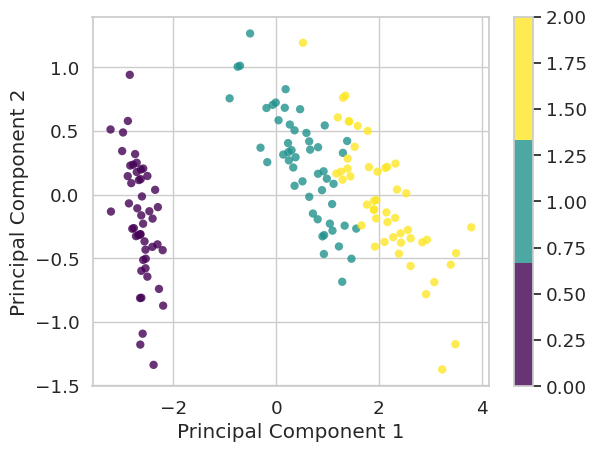


PYDEV DEBUGGER WARNING:
sys.settrace() should not be used when the debugger is being used.
This may cause the debugger to stop working correctly.
If this is needed, please check: 
http://pydev.blogspot.com/2007/06/why-cant-pydev-debugger-work-with.html
to see how to restore the debug tracing back correctly.
Call Location:
  File "/usr/lib/python3.11/doctest.py", line 1523, in run
    sys.settrace(save_trace)



TestResults(failed=0, attempted=4)

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

#Load the test 'iris' dataset
data = datasets.load_iris()
X = data.data
y = data.target

#Instantiate PCA object with 2 PC's (n_components = 2)
pca = PCA(n_components=2)

#Train the model (generate Principal Components)
pca.fit(X)

#Transform the data onto the PC axes
X_proj = pca.transform(X)

#Save the projected data as PC1_data, and PC2_data (for test purposes)
PC1_data = X_proj[:,0]
PC2_data = X_proj[:,1]

#Plot the projected data (see hints below)
plt.scatter(PC1_data, PC2_data, c=y, edgecolor='none', alpha=0.8, cmap=plt.cm.get_cmap('viridis', 3))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()




#Run the doctest module.  DO NOT modify any code below this line!
import doctest
"""
  >>> print(X.shape)
  (150, 4)
  >>> print(X_proj.shape)
  (150, 2)
  >>> print(np.round(PC1_data[17],3))
  -2.648
  >>> print(np.round(PC2_data[17], 3))
  -0.312
"""

doctest.testmod()


**Part 3:  Test with the sklearn.datasets 'breast cancer' data**

- The dataset contains 569 examples of tumors with 30 features each.
- Create a Machine Learning model using Logistic regression and measure performance.
- Use your from-scratch implementation of PCA to transform the data for 2 cases:
  - Retain all Principal Components (PCs)
  - Retain the top 4 PCs
- Rerun Logistic regression and compare performance.

<br>

Follow the steps below and as outlined in the following code cells.  
1.  Import libs and dataset
2.  Load data into dataframe
3.  Train and test a model using all the features with Logistic regression
4.  Rerun with scaled data using Standard Scaling - this will be for PCA processing
5. Perform PCA keeping all components (e.g. components=None) with your from-scratch version (NO ML library version)
6. Generate Scree Plot.  Your plot should look like the following:

![alt text](https://docs.google.com/uc?export=download&id=1G46xsNLl0aZQJ-Keer-66EGC2zOiPkeD)

<br>

7. Run Logistic regression with transformed data
8. Rerun logistic regression with reduced features (4 features) then compare performance.



Make sure your code tests the doctests at the end of the module.

Logistic regression model score on original UNSCALED dataset (all features): 0.9239766081871345
Logistic regression model score on original SCALED dataset (all features): 0.9824561403508771
****** Created from-scratch PCA object *****
Number of components in scree plot: 30


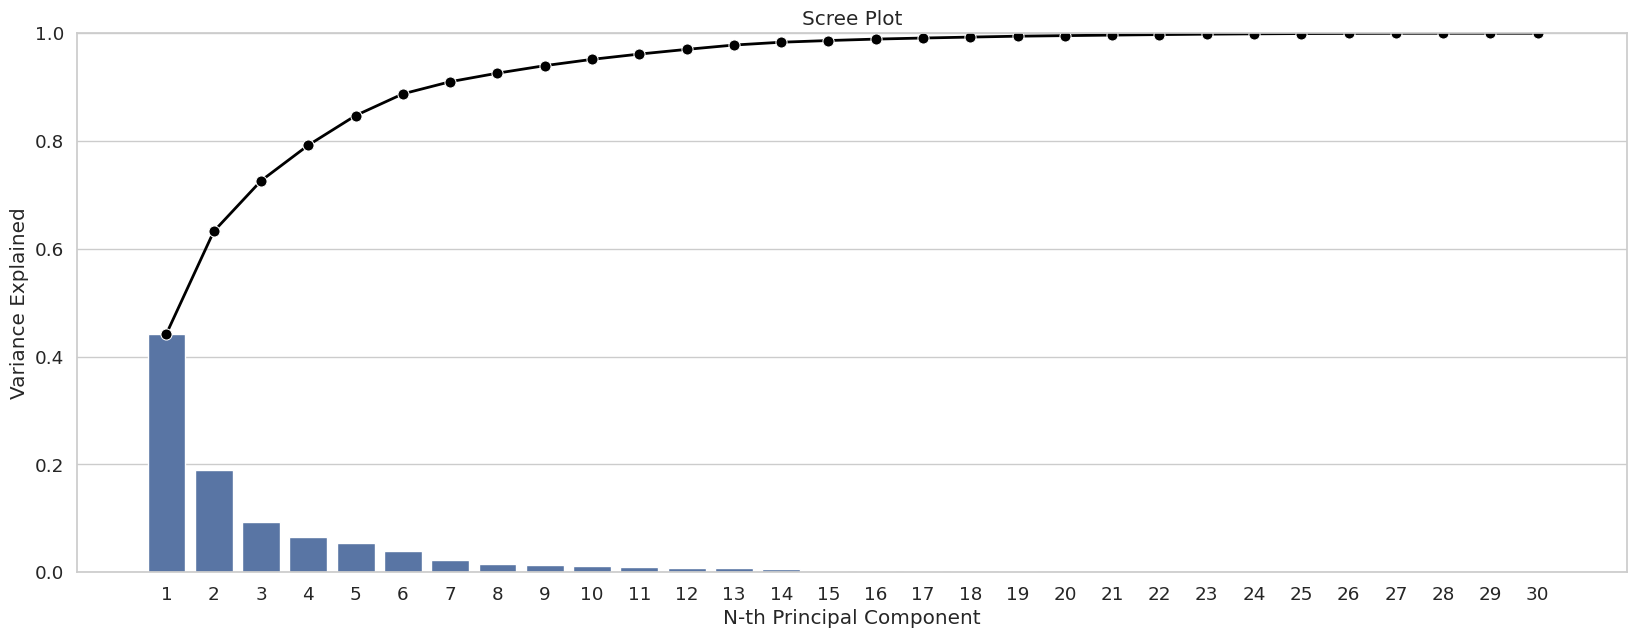

Logistic regression model score on transformed dataset (all PCs): 0.9824561403508771
****** Created from-scratch PCA object *****
Logistic regression model score on transformed dataset (keep 4 PCs): 0.9532163742690059
**********************************************************************
File "__main__", line 7, in __main__
Failed example:
    print(np.round(log_reg_pca_all.score(X_test_pca_all,y_test_pca_all), 3))
Expected:
    0.971
Got:
    0.982
**********************************************************************
File "__main__", line 13, in __main__
Failed example:
    print(np.round(log_reg_pca_4.score(X_test_pca_4,y_test_pca_4), 3))
Expected:
    0.965
Got:
    0.953
**********************************************************************
1 items had failures:
   2 of   6 in __main__
***Test Failed*** 2 failures.


TestResults(failed=2, attempted=6)

In [ ]:
#Step 1.  import libs and dataset
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

breast_cancer = load_breast_cancer()

#print(breast_cancer.feature_names)
#print(len(breast_cancer.feature_names))
#print(breast_cancer.target)
#print(breast_cancer.target_names)
#print(np.array(np.unique(breast_cancer.target, return_counts=True)))

#See cell below, print out a few of the distributions
#For example, see and mean_radius (much info between malignant and benign), smoothness_error plots (not much info between malignant and benign)
#...see cell below

#Step 2.  Load data into dataframe
#    https://pandas.pydata.org/docs/reference/frame.html
#YOUR CODE HERE
df = pd.DataFrame(breast_cancer.data,
                  columns = breast_cancer.feature_names)
df['diagnosis'] = breast_cancer.target


#Step 3.  Train and test a model using all the features with Logistic regression
#    Use the UNSCALED (raw) dataset - we will scale and rerun in the next step.
#    Use a train/test split of 70/30 (30% test), shuffle=True to randomize data
#         prior to splitting, and random state of 12 (for test purposes).
#    https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection
#    https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model
#    https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
#    https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.score

#YOUR CODE HERE
#Assign indep and dep vars (X, y) from your dataframe
#Generate training split (X_train, X_test, y_train, y_test)
#Create model using Logistic Regresssion
#   instantiate LogisticRegression object then train the model
#Generate the score of your model (e.g. _.score(X_test, y_test))

#Read features (X) and labels (y) from dataframe
X = df.drop(['diagnosis'],axis=1)
y = df['diagnosis']
random_state = 12  #do not change - for test purposes

#Generate train/test split = 70/30%, random_state = 12, shuffle = True
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.3, shuffle = True, random_state = random_state)

#Instantiate LogisticRegression object with max_iter = 5000
log_reg = LogisticRegression(max_iter=5000)

#Train the model
log_reg.fit(X_train, y_train)

#---Evaluate the model (Logistic Regression on unscaled data ---
print('Logistic regression model score on original UNSCALED dataset (all features):', log_reg.score(X_test,y_test))


#Step 4.  Rerun with scaled data using Standard Scaling - this will be for PCA processing
#    Rerun logistic regression model on the scaled data to have apples to apples comparison on score after PCA.
#    https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler
#    https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform
#
#YOUR CODE HERE
#Scale data with standard scaler
#Generate training split (X_train_scaled, X_test_scaled, y_train, y_test)
#Perform Logistic Regresssion on your training data (X_train_scaled, y_train)
#Generate the score of your model (e.g. _scaled.score(X_test_scaled, y_test))

#Instantiate StandardScaler object
sc = StandardScaler()

#Scale the data using the fit and transform methods
X_scaled = sc.fit_transform(X, y)

#Generate a train/test split of 70/30 (30% test), shuffle=True to randomize data
#      prior to splitting, and random state of 12 (for test purposes).
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, shuffle = True, random_state = random_state)

#Instantiate LogisticRegression object with max_iter = 5000
log_reg_scaled = LogisticRegression(max_iter=5000)

#Train the model
log_reg_scaled.fit(X_train_scaled,y_train)

#---Evaluate the model (Logistic Regression on scaled data ---
print('Logistic regression model score on original SCALED dataset (all features):', log_reg_scaled.score(X_test_scaled,y_test))


#Step 5. Perform PCA keeping all components (e.g. components=None)
#   Use your from-scratch implementation of PCA (No ML library versions allowed)
#   Make sure to perform PCA using the scaled data
#YOUR CODE HERE

#Instantiate PCA object (your from-scratch implemenation)
#Keep all PC's (n_components = number of features in X)
components = len(X.columns)
pca_all = PCA(components)

# Perform PCA on the scaled data
pca_all.fit(X_scaled)

#Transform the data (project onto the PCs)
X_pca_all = pca_all.transform(X_scaled)




 #Print out attributes (instance variable parameters)
#print('Principal components:', pca_all.components)
#print('Variance ratios:', pca_all.variance_ratio)
#print('Cumulative Variances:', pca_all.cumulative_var*100)


#Step 6. Generate Scree Plot
#        See seaborn plotting hints below
print('Number of components in scree plot:', pca_all.n_components)
PC_components = X_pca_all
sns.set(style='whitegrid', font_scale=1.2)
plt.subplots(figsize=(20, 7))
sns.barplot(x= np.arange(1,pca_all.n_components+1) , y=pca_all.variance_ratio, color='b')
sns.lineplot(x=np.arange(0,pca_all.n_components), y=pca_all.cumulative_var, color='black', linestyle='-', linewidth=2, marker='o', markersize=8)
plt.title('Scree Plot')
plt.xlabel('N-th Principal Component')
plt.ylabel('Variance Explained')
plt.ylim(0, 1)
plt.show()


#Step 7. Rerun Logistic regression with transformed data
#    Use the transformed independent variables, and use the original y
#    Use the same train/test split as previous.
#    Generate training split (X_train_pca, X_test_pca, y_train, y_test)
#    Perform Logistic Regresssion using (X_train_scaled, y_train)
#    Generate score (e.g. _pca.score(X_test_pca, y_test))
#YOUR CODE HERE

X_train_pca_all, X_test_pca_all, y_train_pca_all, y_test_pca_all = train_test_split(X_pca_all, y, test_size =0.3, shuffle = True, random_state =random_state)
log_reg_pca_all = LogisticRegression()
log_reg_pca_all.fit(X_train_pca_all,y_train_pca_all)

#---Evaluate the model---
print('Logistic regression model score on transformed dataset (all PCs):', log_reg_pca_all.score(X_test_pca_all,y_test_pca_all))


#Step 8. Run logistic regression with 4 features then compare performance.
#Instantiate PCA object (your from-scratch implemenation) with 4 components.
pca_4 = PCA(4)

#Fit the model to generate the PCs
pca_4.fit(X_scaled)

#Transform the data (project onto the PCs)
X_pca_4 = pca_4.transform(X_scaled)


#Step 9. Rerun Logistic regression with reduced feature set
#    Use the transformed independent variables, and use the original y
#    Use the same train/test split as previous.
#    Generate training split (X_train_pca, X_test_pca, y_train, y_test)
#    Perform Logistic Regresssion using (X_train_scaled, y_train)
#    Generate score (e.g. _pca.score(X_test_pca, y_test))
#YOUR CODE HERE
X_train_pca_4, X_test_pca_4, y_train_pca_4, y_test_pca_4 = train_test_split(X_pca_4, y,shuffle = True,test_size =0.3, random_state =random_state)
log_reg_pca_4 = LogisticRegression()
log_reg_pca_4.fit(X_train_pca_4,y_train_pca_4)

#---Evaluate the model---
print('Logistic regression model score on transformed dataset (keep 4 PCs):', log_reg_pca_4.score(X_test_pca_4,y_test_pca_4))




#Run the doctest module.  DO NOT modify any code below this line!
import doctest
"""
  >>> print(X_pca_all.shape[1])
  30
  >>> print(np.round(X_pca_all[0][17], 3))
  0.55
  >>> print(np.round(log_reg_pca_all.score(X_test_pca_all,y_test_pca_all), 3))
  0.971
  >>> print(X_pca_4.shape[1])
  4
  >>> print(np.round(X_pca_4[29][3], 3))
  1.911
  >>> print(np.round(log_reg_pca_4.score(X_test_pca_4,y_test_pca_4), 3))
  0.965
"""

doctest.testmod()

#Assignment 2:  Sklearn PCA Implementation

In this assignment, you will rerun Part 2 of assignment 1, this time using the PCA class from the sklearn library.   
(i.e. from sklearn.decomposition import PCA)

<br>

Follow the steps outline in the following code cells.  
Evaluate and reflect on your results, in the text cell following your code.  How did your from-scratch implementation compare to sklearn?

Logistic regression model score on original UNSCALED dataset (all features): 0.9239766081871345
Logistic regression model score on original SCALED dataset (all features): 0.9824561403508771
Variances (Percentage):
[4.51551211e+01 1.81028322e+01 9.17217448e+00 7.32871090e+00
 5.55192195e+00 3.99760258e+00 2.16283106e+00 1.55011456e+00
 1.33859314e+00 1.22561191e+00 9.23809833e-01 7.64610214e-01
 6.51055256e-01 4.78953073e-01 2.98174371e-01 2.79660750e-01
 2.02648479e-01 1.72425963e-01 1.45767545e-01 1.00910683e-01
 9.50253073e-02 8.01673076e-02 6.92464312e-02 5.81413272e-02
 3.68285065e-02 2.67051931e-02 2.26864905e-02 5.12112950e-03
 2.16885036e-03 3.79409669e-04]
Cumulative Variances (Percentage):
[ 45.15512113  63.25795331  72.43012779  79.75883869  85.31076064
  89.30836321  91.47119428  93.02130883  94.35990197  95.58551388
  96.50932371  97.27393393  97.92498918  98.40394226  98.70211663
  98.98177738  99.18442586  99.35685182  99.50261936  99.60353005
  99.69855535  99.77872266  

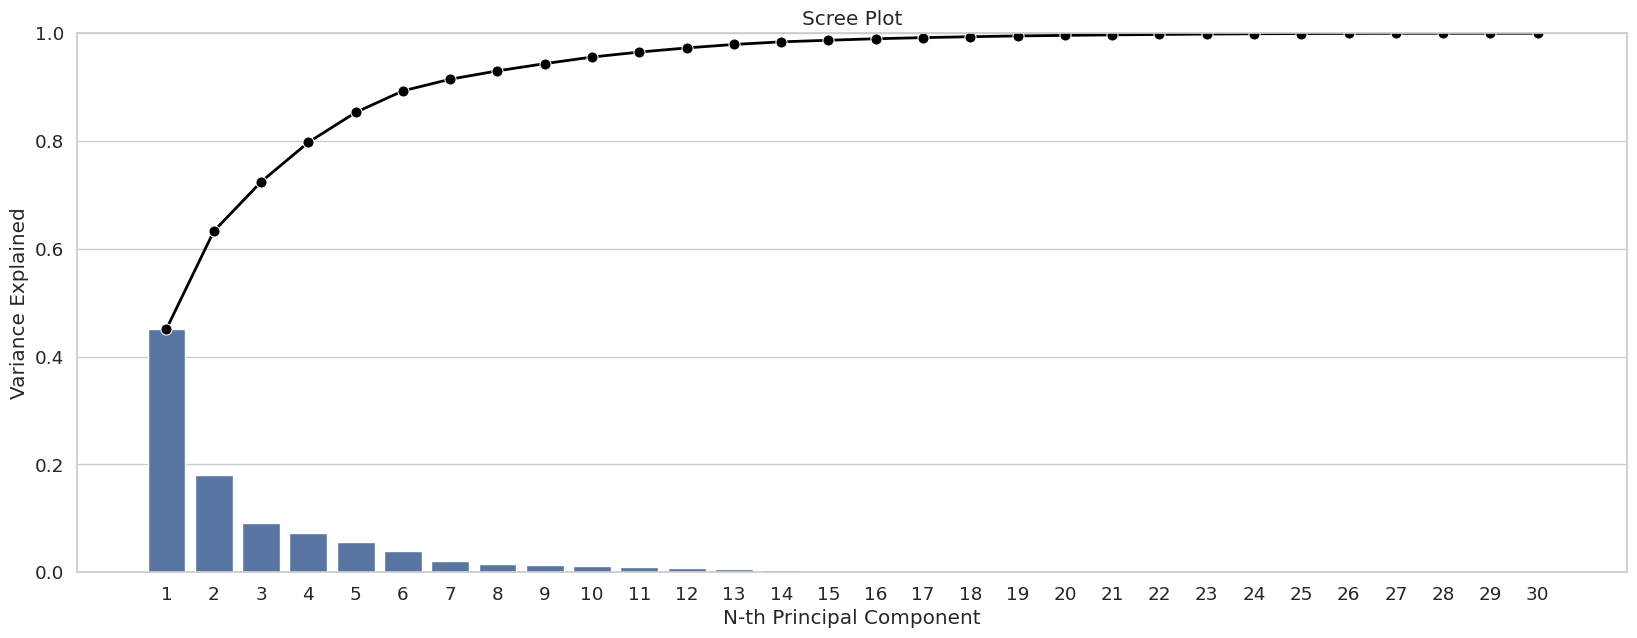

for component 0, three most important features: ['worst perimeter', 'mean concavity', 'mean concave points']
for component 1, three most important features: ['fractal dimension error', 'worst fractal dimension', 'mean fractal dimension']
for component 2, three most important features: ['worst symmetry', 'smoothness error', 'texture error']
Logistic regression model score on transformed dataset(0.7): 0.935672514619883
for component 0, three most important features: ['worst perimeter', 'mean concavity', 'mean concave points']
for component 1, three most important features: ['fractal dimension error', 'worst fractal dimension', 'mean fractal dimension']
for component 2, three most important features: ['worst symmetry', 'smoothness error', 'texture error']
for component 3, three most important features: ['texture error', 'mean texture', 'worst texture']
for component 4, three most important features: ['worst smoothness', 'mean smoothness', 'mean symmetry']
Logistic regression model score o

In [ ]:
#Step 1.  import libs and dataset
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

breast_cancer = load_breast_cancer()

#print(breast_cancer.feature_names)
#print(len(breast_cancer.feature_names))
#print(breast_cancer.target)
#print(breast_cancer.target_names)
#print(np.array(np.unique(breast_cancer.target, return_counts=True)))


#Step 2.  Load data into dataframe
#    https://pandas.pydata.org/docs/reference/frame.html
#YOUR CODE HERE
df = pd.DataFrame(breast_cancer.data, columns = breast_cancer.feature_names)
df['diagnosis'] = breast_cancer.target
y = df['diagnosis']
X = df.drop(['diagnosis'],axis=1)
#3.  Train and test a model using all the features with Logistic regression
#    Use the unscaled (raw) dataset - we will scale and rerun in the next step.
#    Use a train/test split of 70/30 (30% test)
#    https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection
#    https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model
#    https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
#    https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.score

#Assign indep and dep vars (X, y) from your dataframe
#Generate training split (X_train, X_test, y_train, y_test)
#Perform Logistic Regresssion on your training data
#Generate the score of your model (e.g. _.score(X_test, y_test))
#print('Logistic regression model score on original UNSCALED dataset (all features):', _.score(X_test,y_test))
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state =12)
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train,y_train)
print('Logistic regression model score on original UNSCALED dataset (all features):', log_reg.score(X_test,y_test))


#4.  Scale data using Standard Scaling - this will be for PCA processing
#    Rerun logistic regression model on the scaled data to have apples to apples comparison on score after PCA.
#    https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler
#    https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform
#
#Scale data with standard scaler
#Generate training split (X_train_scaled, X_test_scaled, y_train, y_test)
#Perform Logistic Regresssion on your training data (X_train_scaled, y_train)
#Generate the score of your model (e.g. _scaled.score(X_test_scaled, y_test))
#YOUR CODE HERE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state=12)
log_reg_scaled = LogisticRegression(max_iter=5000)
log_reg_scaled.fit(X_train_scaled,y_train)
#---evaluate the model---
print('Logistic regression model score on original SCALED dataset (all features):', log_reg_scaled.score(X_test_scaled,y_test))


#5. Perform PCA keeping all components (e.g. components=None)
#   Make sure to perform PCA using the scaled data
#   https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA
#   https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.fit
#use None to keep all components
#YOUR CODE HERE
pca_all = PCA(None)
pca_all.fit(X_train_scaled)
#6. Generate the explained variances
#   Interpret the results in the following text cell.
#   How much data variability does the 1st PC capture?
#   How much data variability does the 1st + 2nd PCs capture?
#
#SEE PRINTS BELOW
#Generate explained variance ratio
#Generate cumulative variance ratios (_.cumsum())
print("Variances (Percentage):")
print(pca_all.explained_variance_ratio_ * 100)
print("Cumulative Variances (Percentage):")
print(pca_all.explained_variance_ratio_.cumsum() * 100)


#7.  Generate Scree plot to view cumulative variances
#    https://seaborn.pydata.org/generated/seaborn.barplot.html
#    https://seaborn.pydata.org/generated/seaborn.lineplot.html
#YOUR CODE HERE

sns.set(style='whitegrid', font_scale=1.2)
plt.subplots(figsize=(20, 7))
sns.barplot(x= np.arange(1,pca_all.n_components_+1) , y=pca_all.explained_variance_ratio_, color='b')
sns.lineplot(x=np.arange(0,pca_all.n_components_), y=pca_all.explained_variance_ratio_.cumsum(), color='black', linestyle='-', linewidth=2, marker='o', markersize=8)
plt.title('Scree Plot')
plt.xlabel('N-th Principal Component')
plt.ylabel('Variance Explained')
plt.ylim(0, 1)
plt.show()

#8.  Apply PCA with explained variance percentage (70%, 80%, 90%)
#    or use retained number of components corresponding to these %s
#    (use None to keep all components)
#    You will need to rerun PCA with the n_components parameter set.
#    Print the pca components_ to observe the importance each feature contributes
#    to each of the principal components.
#    Identify the top 3 most important features in each component.
for x in [0.7, 0.8, 0.9]:
  pca = PCA(x)
  pca.fit(X_train_scaled)


  for i,component in enumerate(pca.components_):
    topfeats = np.argsort(np.abs(component))[-3:]
    print(f"for component {i}, three most important features: {X.columns[topfeats].tolist()}")

#YOUR CODE HERE


#9.  Transform original features into k PCs
#    Use the scaled input data
#    https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.transform
#YOUR CODE HERE
  transformed_x = pca.transform(X_scaled)

#10. Rerun Logistic regression with reduced feature set
#    Use the transformed independent variables, and use the original y
#    Use the same train/test split as previous.
#    Generate training split (X_train_pca, X_test_pca, y_train, y_test)
#    Perform Logistic Regresssion using (X_train_scaled, y_train)
#    Generate score (e.g. _pca.score(X_test_pca, y_test))
#YOUR CODE HERE
  X_train_pca, X_test_pca, y_train, y_test = train_test_split(transformed_x,y,test_size = 0.3, random_state=12)
  log_reg_pca = LogisticRegression()
  log_reg_pca.fit(X_train_pca,y_train)
#---evaluate the model---
  print(f'Logistic regression model score on transformed dataset({x}):', log_reg_pca.score(X_test_pca,y_test))

#11. Evaluate and reflect on your results (use text cell below)
#   Logistic Regression model performance on original dataset - unscaled and scaled
#   Logistic Regression model performance after feature reduction
#     using PCA to 70%, 80%, 90% cumulative explained variance ratio



(Step 6, Step 11):  Evaluate and reflect on your results here

Step 6: the first component captures approximately 45.155% of the data variability, and the 1st and 2nd component together capture approximately 63.2579% of the data.
The variance list tells us how much variance each Principal component holds, starting with the principal component that holds the most and going down in descending order.
The cumulative variance list is built on the variance list, but is an accumulation of the variance values. For example, the cumulative variance of PC 2 is the variance of PC 1 + the variance of PC 2.

Step 11:Using logistic regression, it is clear to see that scaling the dataset improve regression model performance, jumping from around 0.92 to 0.98. When using PCA, it is slightly worse than scaling the data, but it also depends on the explained variance percentage. The higher the explained variance percentage, the better the regression model performs, which makes sense because more components means accounting for more of the data variance when reducing the features.